In [1]:
import os.path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.nonparametric.smoothers_lowess import lowess

from matplotlib.lines import Line2D

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

In [2]:
prov_order = ["Why", "Where"]

dataset_mapping = {
    "finbench": "Finbench",
    "snb": "SNB-BI"
}

## query name
finbench_query_name = {
    1 : 'RJ-1', 2: 'RJ-2', 3: 'J-1', 4: 'RJ-3', 5: 'S-1',
    6: 'S-2', 7: 'RJ-4', 8: 'J-2', 9: 'R-1', 10: 'MM-1',
    11: 'S-3', 12: 'S-4', 13: 'MM-2', 14: 'MM-3', 15: 'S-5',
    16: 'S-6', 17: 'S-7', 18: 'F-1*', 19: 'SQ-1*', 20:'SQU-1*'
}

snb_query_name = { 1 : 'MM-1', 2: 'MM-2', 3: 'R-1', 4: 'SQU-1', 5: 'MM-3',
                    6: 'MM-4', 7: 'J-1', 8: 'MM-5', 9: 'R-2',  10: 'MMJ-1',
                    11: 'MMJ-2', 12: 'R-3', 13: 'MM-6', 14: 'MMJ-3', 15: 'SQU-2',
                   16: 'MMJ-4', 17: 'S-1', 18: 'J-2', 19: 'J-3', 20: 'F-1*'}

snb_custom_order = ['S-1','F-1*','J-1','J-2','J-3','MM-1','MM-2','MM-3',
                    'MM-4','MM-5','MM-6','MMJ-1','MMJ-2','MMJ-3','MMJ-4','R-1','R-2','R-3','SQU-1','SQU-2']
finbench_custom_order = ['S-1','S-2','S-3','S-4','S-5','S-6','S-7', 'F-1*',
                         'MM-1','MM-2','MM-3','J-1','J-2','R-1','RJ-1','RJ-2','RJ-3','RJ-4','SQ-1*','SQU-1*']

## Query grouping for subplots
finbench_query_groups = {
    "Simple":['S-1','S-2','S-3','S-4','S-5','S-6','S-7','J-1','J-2'] ,
    "Intermediate":['MM-1','MM-2','MM-3','F-1*'],
    "Complex" : ['R-1','RJ-1','RJ-2','RJ-3','RJ-4','SQ-1*','SQU-1*']
}

snb_query_groups = {
    "Simple":['S-1','J-1','J-2','J-3'] ,
    "Intermediate":['MM-1','MM-2','MM-3',
                    'MM-4','MM-5','MM-6','F-1*'],
    "Complex" : ['MMJ-1','MMJ-2','MMJ-3','MMJ-4','R-1','R-2','R-3','SQU-1','SQU-2']
}

all_query_groups = {
    "Finbench": finbench_query_groups,
    "SNB-BI": snb_query_groups
}

## query sub name
finbench_map = {
    ".1.1" : "L1",
    ".1" : "1",
    ".2" :"2",
    ".3" : "3",
    ".4" :"4",
    ".5":"5"
}

custom_orders = {
    "Finbench": finbench_custom_order,
    "SNB-BI": snb_custom_order,
}

legend = {
    "Why": True,
    "Where": False
}

ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"

run_folder = 'run_2'
folder_path = f"result/metrics/{run_folder}"


In [3]:
def map_query_name(qid):
    for suffix, label in finbench_map.items():
        if qid.endswith(suffix):
            return label
    return qid  # fallback if no match

In [23]:
# List all CSV files in the folder
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
df = pd.concat([pd.read_csv(os.path.join(folder_path, f)) for f in files], ignore_index=True)

df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_') ## 9.1.1
df["query_major"] = df["query_id"].str.extract(r'^(\d+)')[0].astype(int)  ##9

df["query_name"] = None
df.loc[df["dataset"] == "finbench", "query_name"] = (
    df.loc[df["dataset"] == "finbench", "query_major"].map(finbench_query_name)
)
df.loc[df["dataset"] == "snb", "query_name"] = (
    df.loc[df["dataset"] == "snb", "query_major"].map(snb_query_name)
)

df["query_sub_name"] = df["query_id"].apply(map_query_name)
df["dataset"] = df["dataset"].map(dataset_mapping)


In [58]:
sub_df_1 = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]
## aggregate per query_name, query_type, parameter
agg2 = (
    sub_df_1.groupby(["provModel", "dataset","scaleFactor", "query_name", "query_type", "parameter"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

## aggregrate per query_name, query_type
agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)

pivot_df = agg.pivot_table(
    index=["dataset", "provModel", "scaleFactor","query_name"],
    columns="query_type",
    values="mean_exec_time"
).reset_index()

# Calculate percentage overhead
pivot_df["perc_overhead"] = ((pivot_df["prov"] - pivot_df["orig"]) / pivot_df["orig"]) * 100

# Optional: preview
agg_overhead = pivot_df.groupby(
    ["dataset", "provModel", "scaleFactor"], as_index=False
).agg(
    min_perc_overhead=("perc_overhead", "min"),
    max_perc_overhead=("perc_overhead", "max")
)

# Preview the results
agg_overhead

,dataset,provModel,scaleFactor,min_perc_overhead,max_perc_overhead
0,Finbench,Where,0.1,23.335003,228.617992
1,Finbench,Where,0.3,6.178822,63.547119
2,Finbench,Where,1.0,0.184005,18.114544
3,Finbench,Where,3.0,0.272710,8.413144
4,Finbench,Why,0.1,28.995559,350.827486
5,Finbench,Why,0.3,10.838135,83.028902
6,Finbench,Why,1.0,0.113176,42.674246
7,Finbench,Why,3.0,0.640768,20.328421
8,SNB-BI,Where,1.0,-1.487752,4426.076209
9,SNB-BI,Where,3.0,-0.100003,1458.016701


Saved overhead line chart to ./result/plots/run_2/Finbench_Why-all.png


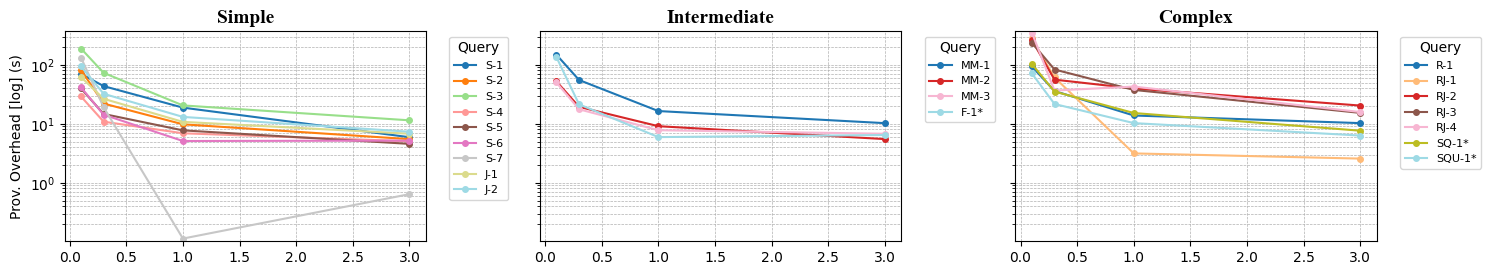

Saved overhead line chart to ./result/plots/run_2/Finbench_Where-all.png


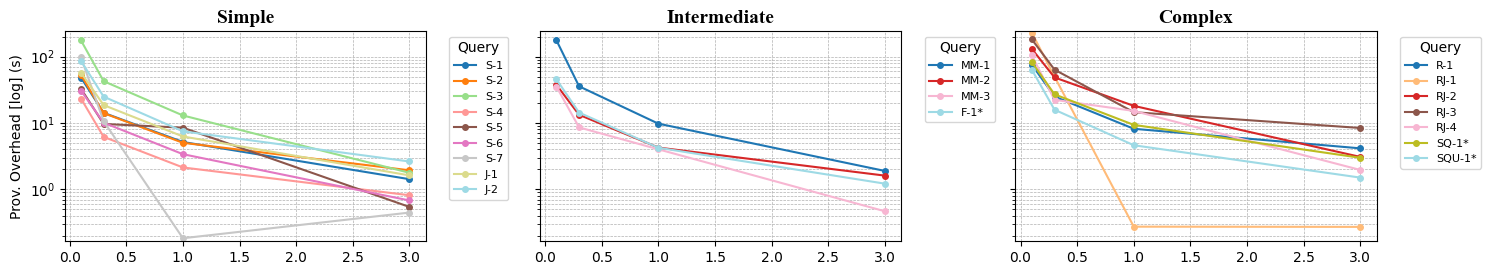

Saved overhead line chart to ./result/plots/run_2/SNB-BI_Why-all.png


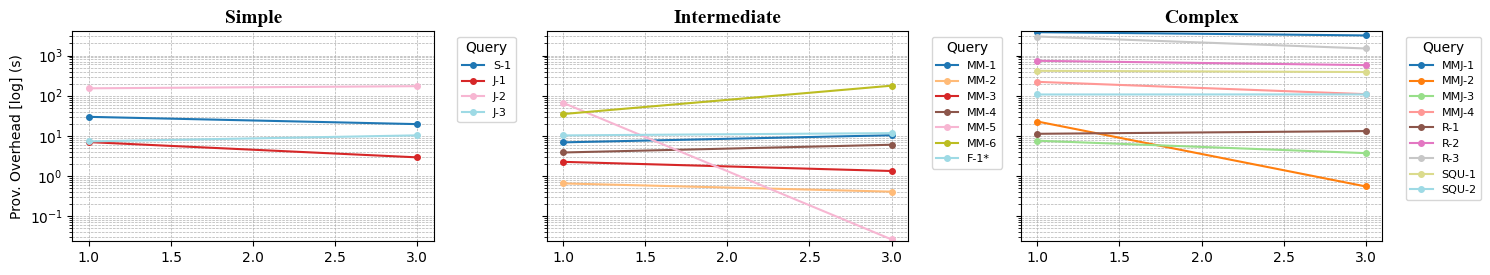

Saved overhead line chart to ./result/plots/run_2/SNB-BI_Where-all.png


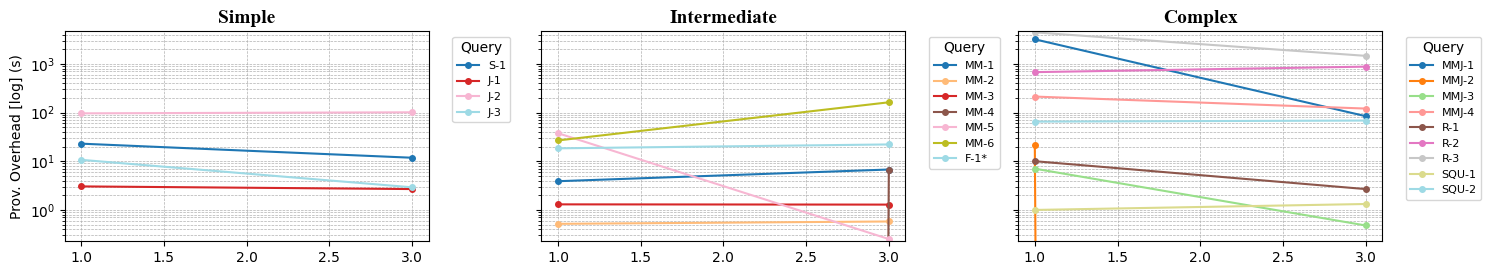

In [40]:
sub_df_1 = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]  ## keep only .3 queries if there's a dot

## aggregate per query_name, query_type, parameter
agg2 = (
    sub_df_1.groupby(["provModel", "dataset","scaleFactor", "query_name", "query_type", "parameter"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

## aggregrate per query_name, query_type
agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)

divisor = 1
for a, (b,dataset_name) in enumerate(dataset_mapping.items()):
    query_groups = all_query_groups[dataset_name]

    for prov_model in prov_order:
        if prov_model not in agg["provModel"].values:
            continue  # skip if this prov_model is not in the data

        # Filter by prov_model and dataset
        sub_model = agg[(agg["provModel"] == prov_model) & (agg["dataset"] == dataset_name)].copy()

        ## Determine y-axis limits
        sub_model_overhead = sub_model.pivot_table(
            index=['scaleFactor', 'query_name'],
            columns='query_type',
            values='mean_exec_time'
        )
        sub_model_overhead['overhead'] = sub_model_overhead['prov']/divisor - sub_model_overhead['orig']/divisor

        all_vals = (sub_model_overhead['overhead']/sub_model_overhead['orig'])*100
        # Y_MIN = all_vals.min() * 0.9
        Y_MIN = max((all_vals[all_vals > 0].min() * 0.9), 1e-5)
        Y_MAX = all_vals.max() * 1.05
        # Compute overhead first

        scale_factors = sorted(sub_model["scaleFactor"].unique())
        n_groups = len(query_groups)

        fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 3), sharey=True)
        if n_groups == 1:
            axes = [axes]

        for i, (group_name, queries) in enumerate(query_groups.items()):

            ax = axes[i]
            queries = [q for q in queries if q in sub_model["query_name"].values]

            colors = plt.colormaps['tab20'].resampled(len(queries))

            for j, query in enumerate(queries):
                query_data = sub_model[sub_model["query_name"] == query].set_index("scaleFactor")

                orig = query_data[query_data["query_type"]=="orig"]["mean_exec_time"].reindex(scale_factors)
                prov = query_data[query_data["query_type"]=="prov"]["mean_exec_time"].reindex(scale_factors)
                overhead = ((prov - orig)/orig)*100

                ax.plot(scale_factors, overhead, marker='o', linestyle='-',
                        label=query, markersize=4, color=colors(j))

            ax.set_yscale("log")
            ax.set_ylim(Y_MIN, Y_MAX)
            # ax.set_xlabel("Scale Factor")
            if i == 0:
                ax.set_ylabel("Prov. Overhead [log] (s)")
            ax.set_title(group_name, fontweight='bold', fontname='Times New Roman', fontsize=14 )
            ax.grid(True, which="both", ls="--", lw=0.5)
            ax.legend(title='Query', fontsize=8, ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')


        # fig.suptitle(f"Provenance Overhead – {prov_model} – {dataset_name}", fontsize=14)
        plt.tight_layout(rect=[0,0,1,0.95])

        os.makedirs(f"./result/plots/{run_folder}", exist_ok=True)
        filename = f"./result/plots/{run_folder}/{dataset_name}_{prov_model}-all.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved overhead line chart to {filename}")
        plt.show()




Saved plot to ./result/plots/run_2/Why_repetitions.png


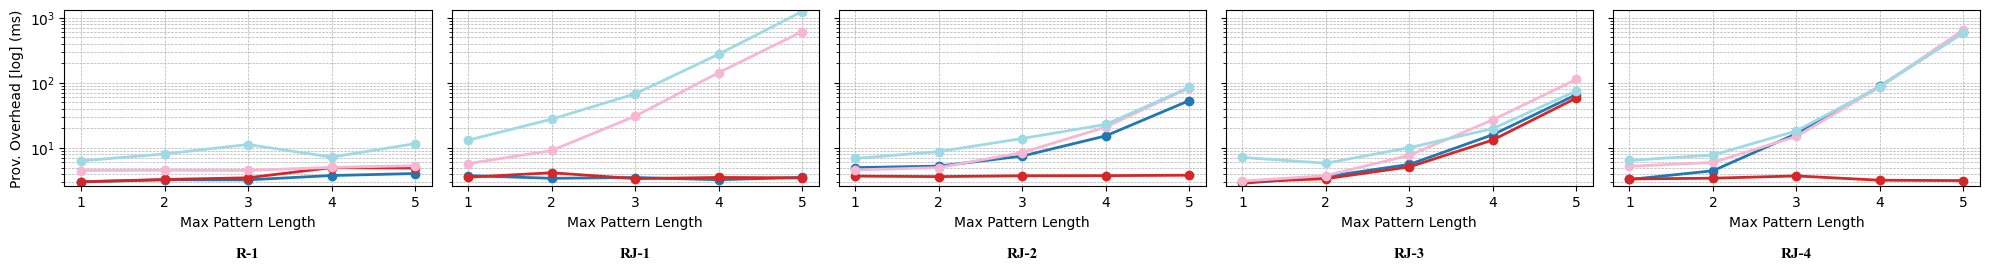

Saved plot to ./result/plots/run_2/Where_repetitions.png


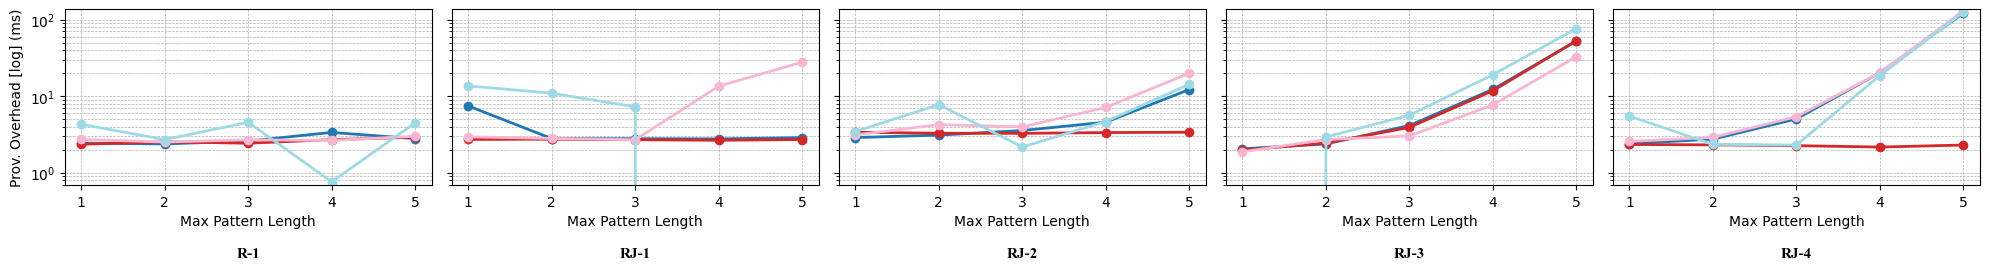

In [49]:
sub_df_2 = df[df["query_id"].str.match(r'^\d+\.(\d)+$')].copy() ## keep only decimal queries

## aggregate per query_name, query_sub_name, query_type, parameter
agg2 = (
    sub_df_2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_sub_name", "query_type", "parameter"], as_index=False )
    .agg(mean_exec_time=("mean", "mean")) )

## aggregate per query_name, query_sub_name, query_type
agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_sub_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)

agg_pivot = agg.pivot_table(
    index=["provModel", "dataset", "scaleFactor", "query_name", "query_sub_name"],
    columns="query_type",
    values="mean_exec_time"
).reset_index()
agg_pivot["overhead"] = agg_pivot["prov"] - agg_pivot["orig"]

for prov_model in prov_order:

    sub_model = agg_pivot[agg_pivot["provModel"] == prov_model]
    if sub_model.empty:
        continue

    majors = sorted(sub_model["query_name"].unique())
    n_major = len(majors)

    fig, axes = plt.subplots(1, n_major, figsize=(4 * n_major, 3), sharey=True)
    if n_major == 1:
        axes = [axes]

    sf_list = sorted(sub_model["scaleFactor"].unique())
    colors = plt.colormaps['tab20'].resampled(len(sf_list))

    # Y-axis limits from overhead values
    vals = sub_model["overhead"].values
    ymin = max(vals[vals>0].min()*0.9, 1e-3)
    # ymin = vals.min() * 0.9
    ymax = vals.max()*1.05

    for ax, major in zip(axes, majors):
        sub_major = sub_model[sub_model["query_name"] == major]

        query_order = sorted(sub_major["query_sub_name"].unique())
        x = np.arange(len(query_order))
        for j, sf in enumerate(sf_list):
            sub_sf = sub_major[sub_major["scaleFactor"] == sf].set_index("query_sub_name").loc[query_order]
            overhead = sub_sf["overhead"].values

            ax.plot(
                x,
                overhead,
                linewidth=2,
                color=colors(j),
                linestyle="-",
                marker='o',
                label=f"SF {sf}" if major == majors[0] else None
            )

        ax.text(
            0.5,
            -0.35,
            major,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
            fontname="Times New Roman",
        )

        ax.set_xticks(x)
        ax.set_xticklabels(query_order)
        ax.set_yscale("log")
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel("Max Pattern Length")
        ax.grid(True, which="both", ls="--", lw=0.5)

    axes[0].set_ylabel("Prov. Overhead [log] (ms)")

    sf_handles = [
        Line2D([0], [0], color=colors(j), lw=2, linestyle="-", label=f"SF {sf}")
        for j, sf in enumerate(sf_list)
    ]

    # fig.legend(
    #     handles=sf_handles,
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 1.15),
    #     ncol=4,
    #     frameon=False,
    #     fontsize=9
    # )

    fig.tight_layout(rect=[0, 0, 1, 1])
    os.makedirs(f"./result/plots/{run_folder}", exist_ok=True)
    filename = f"./result/plots/{run_folder}/{prov_model}_repetitions.png"
    fig.savefig(filename, dpi=300, bbox_inches="tight", facecolor='white')
    print(f"Saved plot to {filename}")
    plt.show()


Saved plot to ./result/plots/run_2/Why_resultSize.png


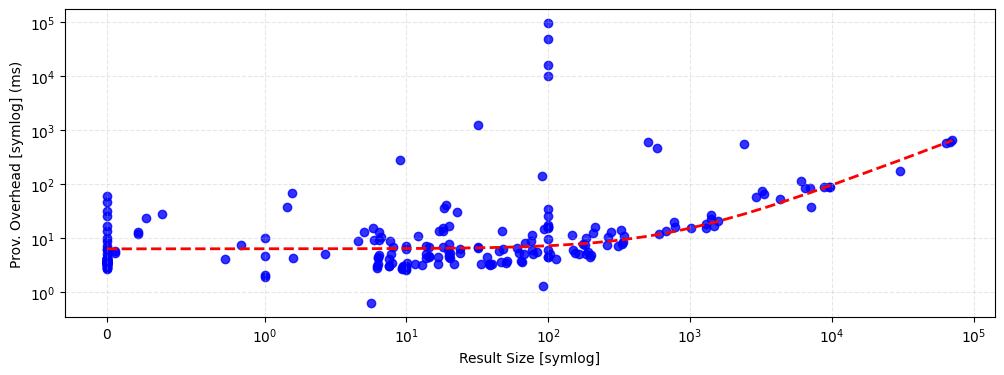

Saved plot to ./result/plots/run_2/Where_resultSize.png


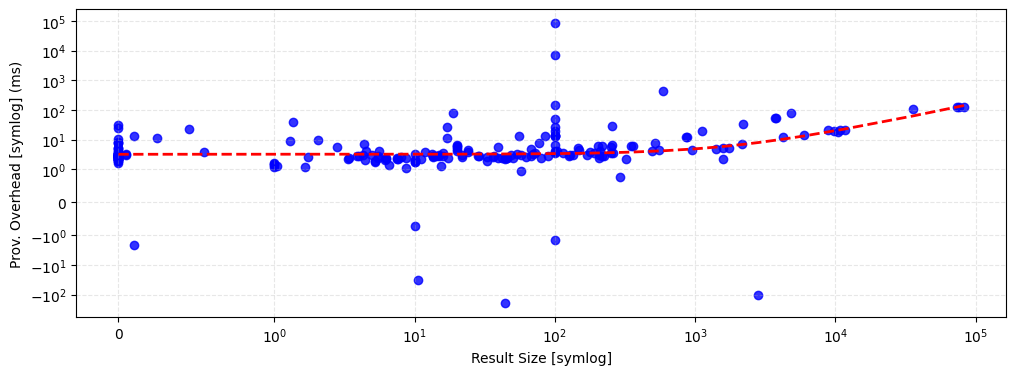

In [60]:
agg2 = (
    df.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_sub_name", "query_type", "parameter"], as_index=False )
    .agg(mean_exec_time=("mean", "mean"), mean_result_size=("resultSize", "mean") ) )

agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_sub_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"), resultSize=("mean_result_size", "mean"))
)

for prov_model in prov_order:
    sub_agg = agg[agg["provModel"]==prov_model]

    pivot = sub_agg.pivot_table(
        index=["provModel", "dataset","scaleFactor", "query_name", "query_sub_name"],
        columns="query_type",
        values=["mean_exec_time", "resultSize"]
    )

    # Compute overhead in execution time
    pivot["overhead"] = pivot["mean_exec_time"]["prov"] - pivot["mean_exec_time"]["orig"]

    x_vals = pivot["resultSize"]["orig"]
    y_vals = pivot["overhead"]

    color_key = pivot.index.get_level_values("dataset").astype(str) + "_SF" + pivot.index.get_level_values("scaleFactor").astype(str)
    # Generate a color map
    unique_keys = color_key.unique()

    fig, ax = plt.subplots(figsize=(12, 4))
    scatter = ax.scatter(x_vals, y_vals, c='blue', marker='o', alpha=0.8)

    lowess_frac = 1  # adjust for smoother/less smooth
    trend = lowess(y_vals, x_vals, frac=lowess_frac, return_sorted=True)
    ax.plot(trend[:,0], trend[:,1], color='red', linestyle='--', linewidth=2, label='Trend line')

    # ===== Axis formatting =====
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("Result Size [symlog]")
    ax.set_ylabel("Prov. Overhead [symlog] (ms)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    os.makedirs(f"./result/plots/{run_folder}", exist_ok=True)
    filename = f"./result/plots/{run_folder}/{prov_model}_resultSize.png"
    fig.savefig(filename, dpi=300, bbox_inches="tight", facecolor='white')
    print(f"Saved plot to {filename}")

    plt.show()

In [ ]:
df[(df["dataset"]=="Finbench") & (df["scaleFactor"]==0.3) & (df["query_name"]=="RJ-4") & (df["provModel"]=="Where") & (df["query_sub_name"]=="L1")& (df["parameter"]=="_17")]

In [ ]:
df["hit"] = (df["resultSize"] >= 1).astype(int)

# Group by dataset, scaleFactor, provModel, query and calculate hit rate
hit_rate = (
    df.groupby(["dataset", "scaleFactor", "provModel", "query_name","query_sub_name"])
    .agg(hit_rate=("hit", "mean"))
    .reset_index()
)

# Optional: format hit_rate as percentage
hit_rate["hit_rate_pct"] = (hit_rate["hit_rate"] * 100)

hit_rate[ (hit_rate["query_name"]=="RJ-4") & (hit_rate["scaleFactor"]==1)]

In [ ]:
# File lists
files1 = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv",
    "2026-01-25_snb_1_naive_latency.csv"
]

files2 = [
    "2026-02-04_finbench_0.1_latency.csv",
    "2026-02-04_finbench_0.3_latency.csv",
    "2026-02-05_finbench_1_latency.csv",
    "2026-02-05_finbench_3_latency.csv",
    "2026-02-05_snb_1_latency.csv",
    "2026-02-06_snb_3_latency.csv"
]

def read_files(file_list):
    df_list = []
    for f in file_list:
        df = pd.read_csv(os.path.join("result/metrics", f))
        df_list.append(df)
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

In [ ]:
df1 = read_files(files1)
df2 = read_files(files2)

provenance_models = ["Why", "Where"]
df1 = df1[df1['provModel'].isin(provenance_models)]
df2 = df2[df2['provModel'].isin(provenance_models)]

def get_query_type(query):
    if query.startswith("prov_"):
        return "prov"
    elif query.startswith("orig_"):
        return "orig"
    else:
        return "unknown"

df1["query_type"] = df1["query"].apply(get_query_type)
df2["query_type"] = df2["query"].apply(get_query_type)

group_cols = ['dataset', 'scaleFactor', 'provModel', 'query_type','query']
df1_grouped = df1.groupby(group_cols)['mean'].mean().reset_index()
df2_grouped = df2.groupby(group_cols)['mean'].mean().reset_index()

comparison = pd.merge(df1_grouped, df2_grouped, on=group_cols, suffixes=('_files1', '_files2'))

comparison['improvement_%'] = ((comparison['mean_files1'] - comparison['mean_files2']) / comparison['mean_files1']) * 100

comparison = comparison.sort_values(by=group_cols).reset_index(drop=True)

# Display the table
print(comparison)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

for prov_model in comparison["provModel"].unique():
    for qtype in comparison["query_type"].unique():

        subset = comparison[
            (comparison["provModel"] == prov_model) &
            (comparison["query_type"] == qtype)
            ]

        if subset.empty:
            continue

        plt.figure(figsize=(12, 5))

        sns.barplot(
            data=subset,
            x="query",
            y="improvement_%",
            hue="scaleFactor"
        )

        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"Improvement (%) — {prov_model.upper()} / {qtype.upper()} queries")
        plt.xlabel("Query")
        plt.ylabel("Improvement (%)  (positive = files2 faster)")

        plt.xticks(rotation=45, ha="right")
        plt.legend(title="ScaleFactor")
        plt.tight_layout()
        plt.show()



In [ ]:
df2 = read_files(files2)

provenance_models = ["Why", "Where"]
df2 = df2[df2['provModel'].isin(provenance_models)]

def get_query_type(query):
    if query.startswith("prov_"):
        return "prov"
    elif query.startswith("orig_"):
        return "orig"
    else:
        return "unknown"

df2["query_type"] = df2["query"].apply(get_query_type)
df2["query"] = df2["query"].str.replace(
    r"^(prov|orig)_", "", regex=True
)
df2["parameter"] = df2["parameter"].str.replace(
    r"^_", "", regex=True
).astype(int)


group_cols = ['dataset', 'scaleFactor', 'provModel', 'query', 'parameter']

# ---- 1. Aggregate runtime ----
runtime_agg = (
    df2.groupby(group_cols + ['query_type'])['mean']
    .mean()
    .reset_index()
)

runtime_pivot = (
    runtime_agg
    .pivot_table(
        index=group_cols,
        columns='query_type',
        values='mean'
    )
    .rename(columns={'orig': 'orig_time', 'prov': 'prov_time'})
    .reset_index()
)

# ---- 2. Aggregate result size ----
result_agg = (
    df2.groupby(group_cols + ['query_type'])['resultSize']
    .mean()      # or .max() if that makes more sense for your data
    .reset_index()
)

result_pivot = (
    result_agg
    .pivot_table(
        index=group_cols,
        columns='query_type',
        values='resultSize'
    )
    .rename(columns={'orig': 'orig_resultSize', 'prov': 'prov_resultSize'})
    .reset_index()
)

# ---- 3. Merge runtime + result size ----
comparison = runtime_pivot.merge(
    result_pivot,
    on=group_cols,
    how='inner'
)

# ---- 4. Keep only cases where prov is slower ----
comparison = comparison[
    comparison['prov_time'].notna() &
    comparison['orig_time'].notna() &
    (comparison['prov_time'] < comparison['orig_time'])
    ]

# ---- 5. Add slowdown percentage ----
comparison['slowdown_%'] = (
                                   (comparison['prov_time'] - comparison['orig_time'])
                                   / comparison['orig_time']
                           ) * 100

comparison.sort_values(by=['dataset','scaleFactor','provModel','query','parameter'], inplace=True)

comparison



